In [1]:
import sys
sys.path.insert(0, "/home/quantumer/dmde_class_perturb-CEDE/python/build/lib.linux-x86_64-3.10")

# import necessary modules
# uncomment to get plots displayed in notebook
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from classy import Class
from scipy.optimize import fsolve
from scipy.interpolate import interp1d
import os
import math
from scipy.interpolate import UnivariateSpline

basedir = os.path.abspath('./')
gdmdir = os.path.join(basedir,'gdm_files')

# esthetic definitions for the plots
font = {'size'   : 16, 'family':'STIXGeneral'}
axislabelfontsize='large'
matplotlib.rc('font', **font)
#matplotlib.mathtext.rcParams['legend.fontsize']='medium'
plt.rcParams["figure.figsize"] = [8.0,6.0]

In [2]:
z_max_pk = 46000       # highest redshift involved
k_per_decade = 400     # number of k values, controls final resolution
k_min_tau0 = 40.       # this value controls the minimum k value in the figure (it is k_min * tau0)
P_k_max_inv_Mpc =1.0   # this value is directly the maximum k value in the figure in Mpc
tau_num_early = 2000   # number of conformal time values before recombination, controls final resolution
tau_num_late = 200     # number of conformal time values after recombination, controls final resolution
tau_ini = 10.          # first value of conformal time in Mpc
tau_label_Hubble = 20. # value of time at which we want to place the label on Hubble crossing
tau_label_ks = 40.     # value of time at which we want to place the label on sound horizon crossing
tau_label_kd = 230.    # value of time at which we want to place the label on damping scale crossing

In [3]:
common_settings = {# which output? transfer functions only
                   'output':'mTk',
                   # LambdaCDM parameters
                   'h':0.67556,
                   'omega_b':0.022032,
                   'omega_cdm':0.12038,
                   'A_s':2.215e-9,
                   'n_s':0.9619,
                   'tau_reio':0.0925,
                   'frac_dmde': 0.333,
                   'g_scf': 1.0,
                   'm_scf': 10,
                   'Omega_k': 0,
                   # Take fixed value for primordial Helium (instead of automatic BBN adjustment)
                   'YHe':0.246,
                   # other output and precision parameters
                   'z_max_pk':z_max_pk,
                   # to get a larger z_max in recfast, 
                   # we must increase both recfast_z_initial 
                   # and the number of sampled values recfast_Nz0
                   # (in order to keep the same stepzize asd in the default: Delta z = 0.5)
                   'recfast_Nz0':z_max_pk*2.,
                   'recfast_z_initial':z_max_pk+1.,
                   #'k_step_sub':'0.01',
                   'k_per_decade_for_pk':k_per_decade,
                   'k_per_decade_for_bao':k_per_decade,
                   'k_min_tau0':k_min_tau0, # this value controls the minimum k value in the figure
                   'perturb_sampling_stepsize':'0.05',
                   'P_k_max_1/Mpc':P_k_max_inv_Mpc,
                   'compute damping scale':'yes', # needed to output and plot Silk damping scale
                   'gauge':'synchronous'}

In [4]:
common_settings = {'output':'mTk,vTk',
                   'frac_dmde' : 1.,
                   'g_scf' : -0.013,
                   'm_scf' : 14.3,
                   'h':0.67556,
                   'omega_b':0.022032,
                   'omega_cdm':0.12038,
                   'A_s':2.215e-9,
                   'n_s':0.9619,
                   'tau_reio':0.0925,
                   'YHe':0.246,
                   'gauge':'synchronous',
                #    'z_max_pk':z_max_pk,
                #    'recfast_Nz0':z_max_pk*2.,
                #    'recfast_z_initial':z_max_pk+1.,
                #    'k_per_decade_for_pk':k_per_decade,
                #    'k_per_decade_for_bao':k_per_decade,
                #    'k_min_tau0':k_min_tau0, 
                #    'perturb_sampling_stepsize':'0.05',
                #    'P_k_max_1/Mpc':P_k_max_inv_Mpc,
                #    'compute damping scale':'yes',
}

In [9]:
common_settings = {'output':'mTk,vTk',                   
                   # LambdaCDM parameters
                   'h':0.67556,
                   'omega_b':0.022032,
                   'omega_cdm':0.12038,
                   'A_s':2.215e-9,
                   'n_s':0.9619,
                   'tau_reio':0.0925,
                   'frac_dmde': 1e-10,
                   'g_scf': 0.0,
                   'm_scf': 0.0,
                   'Omega_k': 0,
                   # Take fixed value for primordial Helium (instead of automatic BBN adjustment)
                   'YHe':0.246,
                   # other output and precision parameters
                   'gauge':'synchronous'}

In [10]:
###############
#   
# call CLASS 
#
###############
M_pre = Class()
M_pre.set(common_settings)
M_pre.compute()

In [11]:
background = M_pre.get_background() # load background table                                                                                                                           
print(background.keys())                                                                                                                                                          
background_tau = background['conf. time [Mpc]'] # read conformal times in background table       
background_z = background['z'] # read redshift
background_tau_at_z = interp1d(background_z,background_tau)

tau_ini = background_tau_at_z(z_max_pk)
print(tau_ini)
times = M_pre.get_current_derived_parameters(['tau_rec','conformal_age'])
tau_rec=times['tau_rec']
tau_0 = times['conformal_age']
tau1 = np.logspace(math.log10(tau_ini),math.log10(5*tau_rec),tau_num_early)
tau2 = np.logspace(math.log10(5*tau_rec),math.log10(tau_0),tau_num_late)[1:]
tau2[-1]=tau_0
tau2[-1] *= 0.999999 # this tiny shift avoids interpolation errors
tau= np.concatenate((tau1,tau2))
tau_num = len(tau)

background_z = background['z'] # read redshift
background_aH = background['H [1/Mpc]']/(1.+background['z'])

background_rho_cdm = background['(.)rho_cdm'] # read rho cdm in background table
background_rho_nu = background['(.)rho_ur'] # read rho nu in background table

background_z_at_tau = interp1d(background_tau,background_z)
a_tau = 1/(1+background_z_at_tau(tau))

background_aH_at_a = interp1d(1/(background_z+1),background_aH)
background_aH_at_tau = interp1d(background_tau,background_aH)

background_rho_cdm_tau = interp1d(background_tau,background_rho_cdm)
background_rho_nu_tau = interp1d(background_tau,background_rho_nu)

#background_phi = []
#or i in range(2199):
 #   one_time = M_pre.get_transfer(background_z_at_tau(tau[i]))
 #   phi = np.array(one_time['phi'])
 #   #phi = list(phi)
 #   background_phi.append(phi[0])
#background_phi = np.array(background_phi)
#print(background_phi)
#background_phi_dot = UnivariateSpline(tau,background_phi,s=0).derivative()(tau)
#print(background['phi_scf'])

dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_lambda', '(.)rho_ur', '(.)rho_crit', '(.)rho_scf', '(.)p_scf', '(.)p_prime_scf', 'phi_scf', "phi'_scf", 'V_scf', "V'_scf", "V''_scf", 'f_scf', "f'_scf", "f''_scf", '(.)rho_tot', '(.)p_tot', '(.)p_tot_prime', 'gr.fac. D', 'gr.fac. f'])
9.89584088923359


/tmp/ipykernel_16612/3669701163.py:8: RuntimeWarning: invalid value encountered in divide
  w_phi_interp = interp1d(1/(1+background_z),background_p_phi/(background_rho_phi))


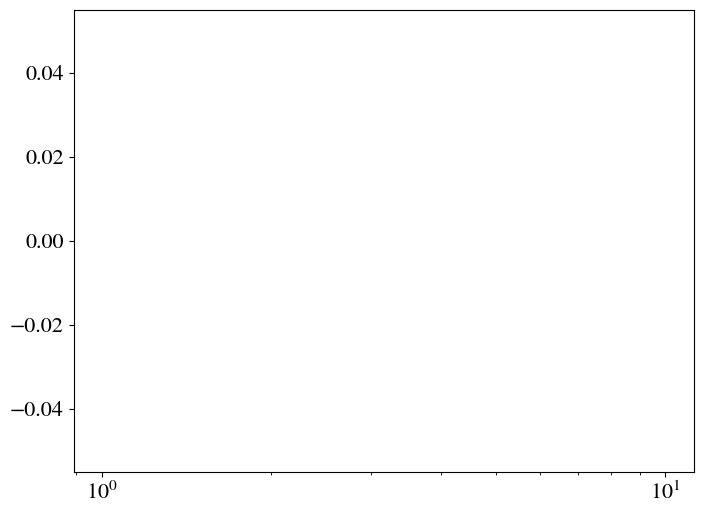

In [12]:
background_rho_phi = background['(.)rho_scf']
background_p_phi = background['(.)p_scf']
# background_rho_phi = interp1d(background_tau,background_rho_phi)
# background_p_phi = interp1d(background_tau,background_p_phi)


# interp1d(1/(1+background_z),background_p_phi)(a_tau)
w_phi_interp = interp1d(1/(1+background_z),background_p_phi/(background_rho_phi))
w_phi_list = w_phi_interp(a_tau)
plt.plot(a_tau,w_phi_list)
plt.xscale('log')

In [13]:
w_T_at_a_interp = interp1d(1/(1+background_z),1/3*background_rho_nu/(background_rho_cdm+background_rho_nu))
w_T_at_a_list = w_T_at_a_interp(a_tau)

w_T_at_a_prime_interp = interp1d(1/(1+background_z),-3.*(1.+background_z)*(1./3.-0.0)**2*background_rho_nu*background_rho_cdm/(background_rho_nu+background_rho_cdm)**2)
w_T_at_a_prime_list = w_T_at_a_prime_interp(a_tau)

ones = np.ones(len(background_z))
ca2_list = w_T_at_a_interp(1/(1+background_z)) - 1./3.*1/(1+background_z)*w_T_at_a_prime_interp(1/(1+background_z))/(ones+w_T_at_a_interp(1/(1+background_z)) )
ca2_a = interp1d(1/(1+background_z),ca2_list)

ones = np.ones(len(a_tau))
ca2_list = w_T_at_a_list - 1./3.*a_tau*w_T_at_a_prime_list/(ones+w_T_at_a_list)
ca2_tau = interp1d(tau,ca2_list)


w_T_tau = interp1d(background_tau,1/3*background_rho_nu/(background_rho_cdm+background_rho_nu))
print(background_z_at_tau(tau[0]))

46000.00000000001


In [ ]:
one_time = M_pre.get_transfer(background_z_at_tau(tau[0]))
k = one_time['k (h/Mpc)']
k_num = len(k)



sigma_d = np.zeros((tau_num,k_num))
delta_d = np.zeros((tau_num,k_num))
theta_d = np.zeros((tau_num,k_num))
cs2_d = np.zeros((tau_num,k_num))
c2eff_d = np.zeros((tau_num,k_num))
Dc2_d = np.zeros((tau_num,k_num))

for i in range(tau_num):
    one_time = M_pre.get_transfer(background_z_at_tau(tau[i])) # transfer functions at each time tau 
    
    delta_d[i,:] = (one_time['d_ur'][:]*background_rho_nu_tau(tau[i]) + background_rho_cdm_tau(tau[i])*one_time['d_cdm'][:])\
    /(background_rho_cdm_tau(tau[i])+background_rho_nu_tau(tau[i]))
    
#     delta_T_std[i]= (background_rho_cdm_at_a_std(a_std[i])*delta_cdm[i]+background_rho_nu_at_a_std(a_std[i])*delta_nu[i])\
#     /(background_rho_cdm_at_a_std(a_std[i])+background_rho_nu_at_a_std(a_std[i]))
#     theta_T_std[i] = ((1+1/3)*background_rho_nu_at_a_std(a_std[i])*theta_nu[i])\
#                     /((background_rho_cdm_at_a_std(a_std[i])+background_rho_nu_at_a_std(a_std[i])*(1.+1./3.)))
    
    theta_d[i,:] = (1+1/3)*one_time['t_ur'][:]*background_rho_nu_tau(tau[i])\
    /(background_rho_cdm_tau(tau[i])+(1+1/3)*background_rho_nu_tau(tau[i]))
    
    cs2_d[i,:] = (1./3.*one_time['d_ur'][:]*background_rho_nu_tau(tau[i]))\
            /(background_rho_cdm_tau(tau[i])*one_time['d_cdm'][:]+background_rho_nu_tau(tau[i])*one_time['d_ur'][:])

    c2eff_d[i,:] = ((k*h)**2*cs2_d[i,:]*delta_d[i,:]+3*background_aH_at_tau(tau[i])*ca2_tau(tau[i])*(1+w_T_tau(tau[i]))*theta_d[i,:])\
        /((k*h)**2*delta_d[i,:]+3*background_aH_at_tau(tau[i])*(1+w_T_tau(tau[i]))*theta_d[i,:])
    
    Dc2_d[i,:] = c2eff_d[i,:]-ca2_tau(tau[i])

    sigma_d[i,:] = ((1+1/3)*background_rho_nu_tau(tau[i])*one_time['shear_ur'])\
             /(background_rho_cdm_tau(tau[i])+(1+1/3)*background_rho_nu_tau(tau[i]))
    
    

: 

In [ ]:
np.savetxt(os.path.join(gdmdir,'k_values.dat'),k)
np.savetxt(os.path.join(gdmdir,'cs2_T.dat'), Dc2_d.ravel())
np.savetxt(os.path.join(gdmdir,'sigma_T.dat'),sigma_d.ravel())
np.savetxt(os.path.join(gdmdir,'w_T.dat'), np.column_stack([a_tau,w_T_at_a_list,w_T_at_a_prime_list]))

In [ ]:
from scipy import interpolate

c2eff_interp=interpolate.interp2d(k,a_tau, c2eff_d, kind='cubic')

c2d_interp=interpolate.interp2d(k,a_tau, cs2_d, kind='cubic')

delta_d_interp=interpolate.interp2d(k,a_tau, delta_d, kind='cubic')
theta_d_interp=interpolate.interp2d(k,a_tau, theta_d, kind='cubic')
sigma_d_interp = interpolate.interp2d(k,a_tau, sigma_d, kind='cubic')

In [ ]:
#############################################
#
# value of k that we want to follow in [1/Mpc]
#
k_val = 0.5  # 1/Mpc
#
# Cosmological parameters and other CLASS parameters
#
common_settings = {# we need to set the output field to something although
                   # the really releveant outpout here will be set with 'k_output_values'
                    #'temperature contributions':'tsw',
                   'gauge':'synchronous',
                    'modes':'s',
                    'lensing':'yes',
                   'output':'tCl,pCl,lCl',
                    #'z_pk':1000,
                    'l_max_scalars':3500,
                   'N_ur': 1e-10,
                   # value of k we want to polot in [1/Mpc]
                   'k_output_values':k_val,
                   # LambdaCDM parameters
                   'h':h,
                   'omega_b':omega_b,
                   'omega_cdm':0,
               #    'Omega_fld': Omega_fld,
               #    'N_gdm': 4,
               #     'use_ppf': 'no',
               #    'fluid_equation_of_state':'INTP',
                #   'gdm_psd_filenames':os.path.join(gdmdir,'w_T.dat')+','+os.path.join(gdmdir,'k_values.dat')+','+os.path.join(gdmdir,'cs2_T.dat')+','+os.path.join(gdmdir,'sigma_T.dat'),
                    'a_ini_over_a_today_default':a_ini_over_a_today_default,
                    'start_large_k_at_tau_h_over_tau_k':start_large_k_at_tau_h_over_tau_k,
                   'A_s':A_s,
                   'n_s':n_s,
                   'tau_reio':tau_reio,
                   # Take fixed value for primordial Helium (instead of automatic BBN adjustment)
                   'YHe':YHe,
                    #'perturb_sampling_stepsize':'0.01'
                   }  

##############
#    
# call CLASS
#
M = Class()
M.set(common_settings)
M.compute()

In [ ]:
#############################################
#
# value of k that we want to follow in [1/Mpc]
#
k_val = 0.5  # 1/Mpc
#
# Cosmological parameters and other CLASS parameters
#
common_settings = {# we need to set the output field to something although
                   # the really releveant outpout here will be set with 'k_output_values'
                   #'temperature contributions':'tsw',
                   'gauge':'synchronous',
                    'modes':'s',
                    'lensing':'yes',
                   'output':'tCl,pCl,lCl',
                   # 'z_pk':1000,
                    'l_max_scalars':3500,
                   #'N_ur': 5,
                   # value of k we want to polot in [1/Mpc]
                   'k_output_values':k_val,
                   # LambdaCDM parameters
                   'h':h,
                   'omega_b':omega_b,
                   'omega_cdm':omega_cdm,
                   #'Omega_fld': 0.26501,
                   #'N_gdm': 4,
                   # 'use_ppf': 'no',
                   #'fluid_equation_of_state':'INTP',
                   #'gdm_psd_filenames':os.path.join(gdmdir,'w_T.dat')+','+os.path.join(gdmdir,'k_values.dat')+','+os.path.join(gdmdir,'cs2_T.dat')+','+os.path.join(gdmdir,'sigma_T.dat'),
                    'a_ini_over_a_today_default':a_ini_over_a_today_default,
                    'start_large_k_at_tau_h_over_tau_k':start_large_k_at_tau_h_over_tau_k,
#                     'ur_fluid_approximation':3,
#                    'ur_fluid_trigger_tau_over_tau_k': 1000.,
                   'A_s':A_s,
                   'n_s':n_s,
                   'tau_reio':tau_reio,
                    #'perturb_sampling_stepsize':'0.01',
                   # Take fixed value for primordial Helium (instead of automatic BBN adjustment)
                   'YHe':YHe
                   }  


#    
# call CLASS
#
M_std = Class()
M_std.set(common_settings)
M_std.compute()

In [ ]:
cl_gdm_lensed = M.lensed_cl(3000)
cl_std_lensed = M_std.lensed_cl(3000)

ell = cl_std_lensed['ell']
factor =ell*(ell+1.)/2./math.pi

plt.loglog(ell,factor*cl_std_lensed['tt'],'r-',label=r'$\mathrm{TT(s)}$')
plt.loglog(ell,factor*cl_gdm_lensed['tt'],'b--',label=r'$\mathrm{TT(s)}$')

plt.loglog(ell,factor*cl_std_lensed['ee'],'r-',label=r'$\mathrm{TT(s)}$')
plt.loglog(ell,factor*cl_gdm_lensed['ee'],'b--',label=r'$\mathrm{TT(s)}$')

plt.loglog(ell,np.abs(factor*cl_std_lensed['te']),'r-',label=r'$\mathrm{TT(s)}$')
plt.loglog(ell,np.abs(factor*cl_gdm_lensed['te']),'b--',label=r'$\mathrm{TT(s)}$')

In [ ]:
background = M.get_background() # load background table
print(background.keys())

In [ ]:
background = M.get_background() # load background table
#print(background.keys())
background_z = background['z'] # read redshift

background_rho_tot = background['(.)rho_tot'] # read rho cdm in background table

background_rho_fld = background['(.)rho_fld'] # read rho cdm in background table

background_rho_tot_at_a = interp1d(1/(1+background_z),background_rho_tot)

w_fld_at_a_interp = interp1d(1/(1+background_z),background['(.)w_fld'])

background_rho_fld_at_z = interp1d(background_z,background_rho_fld)

H_at_a = interp1d(1/(1+background_z),background['H [1/Mpc]'])

rho_fld_at_a = interp1d(1/(1+background_z),background['(.)rho_fld'])
p_fld_at_a = interp1d(1/(1+background_z),background['(.)w_fld']*background['(.)rho_fld'])

# background_rho_tot = background['(.)rho_tot'] # read rho cdm in background table
# background_rho_tot_at_z = interp1d(background_z,background_rho_tot)

# background_rho_tot = background['(.)rho_tot'] # read rho cdm in background table
# background_rho_tot_at_z = interp1d(background_z,background_rho_tot)
all_k = M.get_perturbations()
one_k = all_k['scalar'][0]
print(one_k.keys())
a = one_k['a']

fac = 9*a**2*H_at_a(a)**2/background_rho_tot_at_a(a)/2

rho_tot_at_a = background_rho_tot_at_a(a)
w_fld_at_a = w_fld_at_a_interp(a)

delta_rho_fld = one_k['delta_rho_fld']
delta_rho_plus_p_theta = one_k['rho_plus_p_theta_fld']
delta_p_fld = one_k['delta_p_fld']
psi=one_k['psi']
phi=one_k['phi']
delta_g=one_k['delta_g']

cs2_fld=delta_p_fld/delta_rho_fld
delta_fld = np.zeros(len(a))
rho_plus_p_shear_fld = one_k['rho_plus_p_shear_fld']

theta_fld=np.zeros(len(a))
shear_fld=np.zeros(len(a))


for i in range(len(a)):
    delta_fld[i]= delta_rho_fld[i]/rho_fld_at_a(a[i])
    theta_fld[i]=delta_rho_plus_p_theta[i]/(rho_fld_at_a(a[i])+p_fld_at_a(a[i]))
    shear_fld[i] = rho_plus_p_shear_fld[i]/(rho_fld_at_a(a[i])+p_fld_at_a(a[i]))
# delta_g = one_k['delta_g']
# delta_cdm = one_k['delta_cdm']

# delta_T[i,:] = (background_rho_cdm_tau(tau[i])*one_time['d_cdm'][:]+background_rho_nu_tau(tau[i])*one_time['d_ur'][:])\
#             /(background_rho_T_tau(tau[i]))

cl_tot = M.raw_cl(3500)
cl_lensed = M.lensed_cl(3500)

#print(background['(.)rho_lambda'][-1]/background['(.)rho_crit'][-1])

# all_k = M.get_perturbations()  # this potentially constains scalars/tensors and all k values
# #print(all_k['scalar'][0].keys())
# #    
# one_k = all_k['scalar'][0]     # this contains only the scalar perturbations for the requested k values
# #print(one_k.keys())

# background = M.get_background() # load background table

# #

# one_time = M.get_transfer(1000)
# P_cdm = one_time['d_cdm']
# k_P = one_time['k (h/Mpc)']
#print(one_time.keys())

In [ ]:

background_std = M_std.get_background() # load background table
#print(background_std.keys())
background_z_std = background_std['z'] # read redshift


background_rho_tot_std = background_std['(.)rho_tot'] # read rho cdm in background table
background_rho_tot_at_z_std = interp1d(background_z_std,background_rho_tot_std)

background_rho_tot_at_a_std = interp1d(1/(1+background_z_std),background_std['(.)rho_tot'])
background_rho_cdm_at_a_std = interp1d(1/(1+background_z_std),background_std['(.)rho_cdm'])
background_rho_nu_at_a_std = interp1d(1/(1+background_z_std),background_std['(.)rho_ur'])

background_H_at_a_std = interp1d(1/(1+background_z_std),background_std['H [1/Mpc]'])

background_CalH_at_a_std = interp1d(1/(1+background_z_std),1/(1+background_z_std)*background_std['H [1/Mpc]'])



background_rho_tot_at_a_std = interp1d(1/(1+background_z_std),background_std['(.)rho_tot'])


#background_Da_std = interp1d(background_z_std,background['ang.diam.dist.'])

cl_tot_std = M_std.raw_cl(3500)
cl_lensed_std = M_std.lensed_cl(3500)

all_k_std = M_std.get_perturbations()
one_k_std = all_k_std['scalar'][0]
print(one_k_std.keys())
a_std = one_k_std['a']
tau_std = one_k_std['tau [Mpc]']

w_T_at_a_std = 1/3*background_rho_nu_at_a_std(a_std)\
                        /(background_rho_cdm_at_a_std(a_std)+background_rho_nu_at_a_std(a_std))

rho_std_fld_at_a = background_rho_cdm_at_a_std(a_std)+background_rho_nu_at_a_std(a_std)

rho_tot_at_a_std = background_rho_tot_at_a_std(a_std)

fac_std = 9*a_std**2*background_H_at_a_std(a_std)**2/rho_tot_at_a_std/2

delta_cdm = one_k_std['delta_cdm']
theta_cdm=one_k_std['theta_cdm']

delta_nu = one_k_std['delta_ur']
theta_nu = one_k_std['theta_ur']
sigma_nu = one_k_std['shear_ur']

psi_std=one_k_std['psi']
phi_std=one_k_std['phi']
h_prime_over_2=one_k_std['metric_continuity']

delta_g_std=one_k_std['delta_g']

delta_T_std = np.zeros(len(a_std))
theta_T_std = np.zeros(len(a_std))
cs2_std =np.zeros(len(a_std))
cs2_eff = np.zeros(len(a_std))
sigma_T_std =np.zeros(len(a_std))

ca2_a_std = ca2_a(a_std)

for i in range(len(a_std)):
    delta_T_std[i]= (background_rho_cdm_at_a_std(a_std[i])*delta_cdm[i]+background_rho_nu_at_a_std(a_std[i])*delta_nu[i])\
    /(background_rho_cdm_at_a_std(a_std[i])+background_rho_nu_at_a_std(a_std[i]))
    theta_T_std[i] = ((1+1/3)*background_rho_nu_at_a_std(a_std[i])*theta_nu[i])\
                    /((background_rho_cdm_at_a_std(a_std[i])+background_rho_nu_at_a_std(a_std[i])*(1.+1./3.)))
    cs2_std[i]  = 1/3*delta_nu[i]*background_rho_nu_at_a_std(a_std[i])/(background_rho_cdm_at_a_std(a_std[i])*delta_cdm[i]+background_rho_nu_at_a_std(a_std[i])*delta_nu[i])
    cs2_eff[i] = k_val**2*cs2_std[i]*delta_T_std[i]+3*ca2_a(a_std[i])*background_CalH_at_a_std(a_std[i])*(1+w_T_at_a_std[i])*theta_T_std[i]
    cs2_eff[i] = cs2_eff[i]/(k_val**2*delta_T_std[i]+3*background_CalH_at_a_std(a_std[i])*(1+w_T_at_a_std[i])*theta_T_std[i])
    sigma_T_std[i]=(1+1/3)*background_rho_nu_at_a_std(a_std[i])*sigma_nu[i]\
            /(background_rho_cdm_at_a_std(a_std[i])+(1+1/3)*background_rho_nu_at_a_std(a_std[i]))

delta_T_std_interp = UnivariateSpline(tau_std,delta_T_std,s=0)
theta_T_std_interp = UnivariateSpline(tau_std,theta_T_std,s=0)

ones = np.ones(len(a_std))
delta_std = np.ones(len(a_std))
theta_std = np.ones(len(a_std))
sigma_std = np.ones(len(a_std))
c2eff_std = np.zeros(len(a_std))
c2d_std= np.zeros(len(a_std))
for i in range(len(a_std)):
    delta_std[i] = delta_d_interp(k_val/h,a_std[i])[0]
    theta_std[i] = theta_d_interp(k_val/h,a_std[i])[0]
    c2eff_std[i] = c2eff_interp(k_val/h,a_std[i])[0]
    sigma_std[i] = sigma_d_interp(k_val/h,a_std[i])[0]
    c2d_std[i] = c2d_interp(k_val/h,a_std[i])[0]



RHS_cont = -(theta_T_std+h_prime_over_2)*(1+w_T_at_a_std)-3*background_CalH_at_a_std(a_std)*(c2eff_std-w_T_at_a_std)*delta_T_std\
             -9*background_CalH_at_a_std(a_std)**2*(c2eff_std-ca2_a_std)*(1+w_T_at_a_std)*theta_T_std/k_val**2

RHS_euler = -background_CalH_at_a_std(a_std)*(ones-3*c2eff_std)*theta_T_std+c2eff_std/(ones+w_T_at_a_std)*delta_T_std*k_val**2-k_val**2*sigma_std

#RHS_cont = -(1+w_T_at_a_std)*(theta_T_std+h_prime_over_2)-3*background_CalH_at_a_std(a_std)*(c2d_std-w_T_at_a_std)*delta_T_std

# (1+1/3)*background_rho_nu_tau(tau[i])*one_time['shear_ur'][:]\
#             /(background_rho_cdm_tau(tau[i])+(1+1/3)*background_rho_nu_tau(tau[i]))
    
# delta_g = one_k['delta_g']
# delta_cdm = one_k['delta_cdm']

# delta_T[i,:] = (background_rho_cdm_tau(tau[i])*one_time['d_cdm'][:]+background_rho_nu_tau(tau[i])*one_time['d_ur'][:])\
#             /(background_rho_T_tau(tau[i]))



# delta_T= interp1d((background_rho_cdm_tau(tau[i])*one_time['d_cdm'][:]+background_rho_nu_tau(tau[i])*one_time['d_ur'][:])\
#             /(background_rho_T_tau(tau[i]))

# all_k = M.get_perturbations()  # this potentially constains scalars/tensors and all k values
# #print(all_k['scalar'][0].keys())
# #    
# one_k = all_k['scalar'][0]     # this contains only the scalar perturbations for the requested k values
# #print(one_k.keys())

#background = M.get_background() # load background table
#print(background['(.)rho_lambda'][-1]/background['(.)rho_crit'][-1])
# #

# one_time_std = M_std.get_transfer(1000)
# P_cdm_std = one_time_std['d_cdm']
# k_P_std = one_time_std['k (h/Mpc)']


In [ ]:
plt.xlabel(r'$a$')
plt.grid()

# plt.ylim([-0.5,0.5])
# plt.xlim([1e-5,1e-3])

# plt.semilogx(a_std,cs2_std,'r-',label=r'$\theta_b$')
# plt.semilogx(a_std,c2d_std,'b--',label=r'$\theta_b$')

plt.semilogx(a_std,c2eff_std,'g-',label=r'$\theta_b$')
plt.semilogx(a_std,cs2_eff,'k--',label=r'$\theta_b$')

# plt.semilogx(a_std,w_T_at_a_std,'r-',label=r'$\theta_b$')
# plt.semilogx(a_std,w_T_at_a_interp(a_std),'k--',label=r'$\theta_b$')



In [ ]:
plt.xlabel(r'$a$')
plt.grid()

plt.semilogx(a_std,RHS_euler,'r-',label=r'$\theta_b$')
plt.semilogx(a_std,theta_T_std_interp.derivative()(tau_std),'b--',label=r'$\theta_b$')



In [ ]:
plt.xlabel(r'$a$')
plt.grid()

plt.ylim([-0.5,0.5])
plt.xlim([1e-5,1e-3])

plt.semilogx(a_std,RHS_cont,'r-',label=r'$\theta_b$')
plt.semilogx(a_std,delta_T_std_interp.derivative()(tau_std),'b--',label=r'$\theta_b$')


In [ ]:
plt.xlabel(r'$a$')
plt.grid()

plt.semilogx(a_std,cs2_std,'r-',label=r'$\theta_b$')
plt.semilogx(a_std,c2d_interp(k_val/h,a_std),'g--',label=r'$\theta_b$')

plt.semilogx(a_std,sigma_T_std,'r-',label=r'$\theta_b$',lw=2)
#plt.semilogx(a,shear_fld,'g-',label=r'$\theta_b$',lw=2)
plt.semilogx(a_std,sigma_d_interp(k_val/h,a_std),'b:')

cs2_std[1000]/c2d_interp(k_val/h,a_std[1000])

In [ ]:
plt.xlabel(r'$a$')
plt.grid()

plt.loglog(a_std,np.abs(delta_T_std),'r-',label=r'$\theta_b$')
plt.loglog(a,np.abs(delta_fld),'g--',label=r'$\theta_b$')


In [ ]:
plt.xlabel(r'$a$')
plt.grid()

plt.loglog(a_std,np.abs(theta_T_std),'r-',label=r'$\theta_b$')
plt.loglog(a,np.abs(theta_fld),'g--',label=r'$\theta_b$')

In [ ]:
plt.xlabel(r'$a$')
plt.grid()

plt.semilogx(a_std,sigma_T_std,'r-',label=r'$\theta_b$',lw=2)
#plt.semilogx(a,shear_fld,'g-',label=r'$\theta_b$',lw=2)
plt.semilogx(a_std,sigma_d_interp(k_val/h,a_std),'b:')

In [ ]:
plt.xlabel(r'$a$')
plt.grid()

plt.semilogx(a_std,w_T_at_a_std,'r-',label=r'$\theta_b$')
plt.semilogx(a,w_fld_at_a,'g--',label=r'$\theta_b$')

In [ ]:
plt.xlabel(r'$a$')
#plt.title(r'$\mathrm{Transfer} (\tau,k) \,\,\, \mathrm{for} \,\,\, k=%g \,\,\, [1/\mathrm{Mpc}]$'%k)
plt.grid()

# plt.semilogx(a,fac*rho_plus_p_shear_fld,'k-',label=r'$\theta_b$')
# plt.semilogx(a_std,sigma_T_std*(w_T_at_a_std+1)*rho_std_fld_at_a*fac_std,'r-',label=r'$\theta_b$')

plt.semilogx(a_std,phi_std-psi_std,'k--',label=r'$\theta_b$')
plt.semilogx(a,phi-psi,'b--',label=r'$\theta_b$')

# plt.loglog(a_std,np.abs(delta_T_std),'r-',label=r'$\theta_b$')
# #plt.loglog(a_list,np.abs(delta_T_interp(k_val/h,a_list)),'b--',label=r'$\theta_b$')
# plt.loglog(a,np.abs(delta_fld),'g--',label=r'$\theta_b$')

# delta_T_std_interp=interp1d(a_std,delta_T_std)
# delta_fld_interp=interp1d(a,delta_fld)

#fac_interp=interp1d(a,fac*rho_plus_p_shear_fld)
#fac_std_interp=interp1d(a_std,sigma_T_std*(w_T_at_a_std+1)*rho_std_fld_at_a*fac_std)

# a_list=np.logspace(-6,0,500)

#rat=rho_fld_at_a(a_list)/fac_std_interp(a_list)

#rat = delta_fld_interp(a_list)/delta_T_interp(a_list)

#plt.semilogx(a_std,np.abs(psi_std+delta_g_std/4),'b-',label=r'$\theta_b$',lw=3)
#plt.semilogx(a_std,np.abs(psi_std),'b-',label=r'$\theta_b$',lw=3)
#plt.semilogx(a_std,np.abs(phi_std),'r-',label=r'$\theta_b$',lw=3)

#plt.semilogx(a_std,np.abs(phi_std),'g-',label=r'$\theta_b$',lw=3)
#plt.semilogx(a,np.abs(psi),'g--',label=r'$\theta_b$',lw=3)
#plt.semilogx(a,np.abs(phi),'m--',label=r'$\theta_b$',lw=3)
#plt.semilogx(a_std,sigma_T,'b-',label=r'$\theta_b$',lw=3)
#plt.semilogx(a,cs2_fld,'r--',label=r'$\theta_b$',lw=3)

#plt.semilogx(a_std,cs2_std,'r-',label=r'$\theta_b$',lw=4)
#plt.semilogx(a_std,delta_P_T_interp(k_val/h,a_std),'k:',label=r'$\theta_b$',lw=4)

# plt.semilogx(a_std,sigma_T_std,'r-',label=r'$\theta_b$',lw=2)
# plt.semilogx(a_std,sigma_T_interp(k_val/h,a_std),'k:',label=r'$\theta_b$',lw=3)

#plt.semilogx(a,shear_fld)

#plt.semilogx(a_list,rho_std_fld_at_a(a_list)/rho_fld_at_a(a_list),'r-',label=r'$\theta_b$',lw=3)

#plt.loglog(a_std,np.abs(delta_cdm_trans_interp(k_val*1.5,a_std)),'r-',label=r'$\theta_b$')

#plt.loglog(a_list,np.abs(delta_T_std_interp(a_list)),'r-',label=r'$\theta_b$')
#plt.loglog(a_list,np.abs(delta_T_interp(k_val/h,a_list)),'b--',label=r'$\theta_b$')
#plt.loglog(a_list,np.abs(delta_fld_interp(a_list)),'g--',label=r'$\theta_b$')

#tab=sigma_T_interp(k_val/h,a_std[:])



#plt.semilogx(a_list,rat,'k-',label=r'$\theta_b$')




#plt.semilogx(a_std,rat,'g--',label=r'$\theta_b$')
#plt.semilogx(a_std,),'r-',label=r'$\theta_b$')

#plt.semilogx(a,psi,'g--',label=r'$\theta_b$')



#plt.loglog(a,np.abs(delta_fld),'b-',label=r'$\theta_b$')
#plt.loglog(a_std,np.abs(sigma_T),'g-',label=r'$\theta_b$')


#plt.legend(loc='right',bbox_to_anchor=(1.4, 0.5))
#plt.savefig('one_k.pdf',bbox_inches='tight')
#

In [ ]:
fac_interp=interp1d(a,shear_fld)
fac_std_interp=interp1d(a_std,sigma_T_std)


print(fac_interp(2e-6))
print(fac_std_interp(2e-6))
print(sigma_T_interp(k_val/h,2e-6))

In [ ]:
#################
#
# start plotting
#
#################
#
#plt.ylim([-0.0001,0.0001])
#plt.ylim([1.e-8,10])

z_list=np.logspace(0,7.5,500)

rat=background_rho_tot_at_z_std(z_list)/background_rho_tot_at_z(z_list)

plt.grid()

plt.semilogx(z_list,rat,'r-',label=r'$\mathrm{TT(s)}$')

In [ ]:
cl_tot_std['pp'][3]

In [ ]:
#################
#
# start plotting
#
#################
#
plt.xlim([2,3500])
#plt.ylim([1.e-8,10])
#plt.xlabel(r"$\ell$")
#plt.ylabel(r"$\ell (\ell+1) C_l^{XY} / 2 \pi \,\,\, [\times 10^{10}]$")
#plt.title(r"$r=0.1$")
plt.grid()
#
ell = cl_lensed_std['ell']
factor = 1.e10*ell*(ell+1.)/2./math.pi

lens_factor = 1.e7*(ell*(ell+1.))**2

#
#plt.semilogx(ell,factor*cl_tot['tt'],'r-',label=r'$\mathrm{TT(s)}$')
#plt.loglog(ell,factor*cl_tot_std['tt'],'b:',label=r'$\mathrm{TT_std(s)}$')

plt.plot(ell,(cl_lensed_std['tt']-cl_lensed['tt'])/(cl_lensed_std['tt']+1e-30),'r-',label=r'$\mathrm{TT(s)}$')
#plt.plot(ell,(cl_tot_std['pp']-cl_tot['pp'])/(cl_tot_std['pp']+1e-30),'b-',label=r'$\mathrm{TT(s)}$')

#plt.loglog(ell,np.abs((cl_tot_std['pp']-cl_tot['pp'])/cl_tot_std['pp']),'r-',label=r'$\mathrm{TT(s)}$')
#plt.semilogx(ell,lens_factor*cl_tot['pp'],'b-',label=r'$\mathrm{TT(s)}$')

#plt.plot(ell,(cl_tot_std['tt']-cl_lensed_std['tt'])/(cl_tot_std['tt']+1e-30),'r-',label=r'$\mathrm{TT(s)}$')
#plt.plot(ell,(cl_tot['tt']-cl_lensed['tt'])/(cl_tot['tt']+1e-30),'b-',label=r'$\mathrm{TT(s)}$')


#plt.loglog(ell,factor*cl_tot['ee'],'b-',label=r'$\mathrm{EE(s)}$')
#plt.loglog(ellt,factort*cl_tot['bb'],'g:',label=r'$\mathrm{BB(t)}$')
plt.legend(loc='right',bbox_to_anchor=(1.4, 0.5))
plt.savefig('Cl_comp.pdf',bbox_inches='tight')

In [ ]:
background_rho_fld = background['(.)rho_fld'] # read confromal times in background table
background_tau = background['conf. time [Mpc]'] # read confromal times in background table

rho_fld_at_tau = interp1d(background_tau,background_rho_fld)


#    
tau = one_k['tau [Mpc]']
delta_rho_fld = one_k['delta_rho_fld']
delta_g = one_k['delta_g']
delta_cdm = one_k['delta_cdm']

delta_fld = np.zeros(len(tau))

for i in range(len(tau)):
    delta_fld[i]= delta_rho_fld[i]/rho_fld_at_tau(tau[i])
    
delta_p_fld= one_k['delta_p_fld']
cs2_fld=delta_p_fld/delta_rho_fld
a = one_k['a']

quantities = M.get_current_derived_parameters(['tau_rec'])
# print times.viewkeys()
tau_rec = quantities['tau_rec']
#
# use table of background quantitites to find the time of
# Hubble crossing (k / (aH)= 2 pi), sound horizon crossing (k * rs = 2pi)
#

background_tau = background['conf. time [Mpc]'] # read confromal times in background table
background_z = background['z'] # read redshift

#################
#
# start plotting
#
#################
#    
#plt.xlim([tau[0],tau_rec*1.3])
#plt.ylim([-1.3*Theta0_amp,1.3*Theta0_amp])
plt.xlabel(r'$k\tau \,\,\, \mathrm{[Mpc]}$')
#plt.title(r'$\mathrm{Transfer} (\tau,k) \,\,\, \mathrm{for} \,\,\, k=%g \,\,\, [1/\mathrm{Mpc}]$'%k)
plt.grid()
#
#plt.axvline(x=tau_Hubble,color='r')
#plt.axvline(x=tau_s,color='y')
#plt.axvline(x=tau_eq,color='k')
#plt.axvline(x=tau_rec,color='k')
#
# plt.annotate(r'Hubble cross.',
#                 xy=(tau_Hubble,1.08*Theta0_amp),
#                 xytext=(0.15*tau_Hubble,1.18*Theta0_amp),
#                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
# plt.annotate(r'sound hor. cross.',
#                  xy=(tau_s,-1.0*Theta0_amp),
#                  xytext=(1.5*tau_s,-1.2*Theta0_amp),
#                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
# plt.annotate(r'eq.',
#                  xy=(tau_eq,1.08*Theta0_amp),
#                  xytext=(0.45*tau_eq,1.18*Theta0_amp),
#                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
# plt.annotate(r'rec.',
#                  xy=(tau_rec,1.08*Theta0_amp),
#                  xytext=(0.45*tau_rec,1.18*Theta0_amp),
#                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
# #
# Possibility to add functions one by one, saving between each (for slides)
#

#plt.loglog(a,np.abs(delta_fld),'g-',label=r'$\theta_b$')
plt.loglog(k*tau,np.abs(delta_cdm),'b-',label=r'$\theta_b$')
plt.loglog(k*tau,np.abs(delta_g),'g-',label=r'$\theta_b$')
plt.loglog(k*tau,np.abs(delta_fld),'r-',label=r'$\theta_{cdm}$')

#plt.legend(loc='right',bbox_to_anchor=(1.4, 0.5))
#plt.savefig('one_k.pdf',bbox_inches='tight')
#

In [ ]:
##############
#    
# call CLASS
#
M = Class()
M.set(common_settings)
M.compute()

all_k = M.get_perturbations()  # this potentially constains scalars/tensors and all k values
#print(all_k['scalar'][0].keys())
#    
one_k = all_k['scalar'][0]     # this contains only the scalar perturbations for the requested k values
#print(one_k.keys())

background = M.get_background() # load background table
#print(background.keys())
#

In [ ]:
cl_tot_std = M.raw_cl(2500)
cl_lensed_std = M.lensed_cl(2500)

#################
#
# start plotting
#
#################
#
#plt.xlim([2,3000])
#plt.ylim([1.e-8,10])
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell (\ell+1) C_l^{XY} / 2 \pi \,\,\, [\times 10^{10}]$")
plt.title(r"$r=0.1$")
plt.grid()
#
ell = cl_tot['ell']
factor = 1.e10*ell*(ell+1.)/2./math.pi
#
plt.loglog(ell,factor*cl_tot['tt'],'r-',label=r'$\mathrm{TT(s)}$')
#plt.loglog(ell,factor*cl_tot['ee'],'b-',label=r'$\mathrm{EE(s)}$')
#plt.loglog(ellt,factort*cl_tot['bb'],'g:',label=r'$\mathrm{BB(t)}$')
plt.legend(loc='right',bbox_to_anchor=(1.4, 0.5))

In [ ]:
#############################################
#
# value of k that we want to follow in [1/Mpc]
#
k = 0.5  # 1/Mpc
#
# Cosmological parameters and other CLASS parameters
#
common_settings = {# we need to set the output field to something although
                   # the really releveant outpout here will be set with 'k_output_values'
                   'gauge':'synchronous',
                   'output':'mPk',
                   # value of k we want to polot in [1/Mpc]
                   'k_output_values':k,
                   # LambdaCDM parameters
                   'h':0.67556,
                   'omega_b':0.022032,
                   'omega_cdm':0.12038,
                   'A_s':2.215e-9,
                   'n_s':0.9619,
                   'tau_reio':0.0925,
                   # Take fixed value for primordial Helium (instead of automatic BBN adjustment)
                   'YHe':0.246,
                   # other options and settings
                   'compute damping scale':'yes' # needed to output the time of damping scale crossing
                   }  
##############
#    
# call CLASS
#
M = Class()
M.set(common_settings)
M.compute()
#
# load perturbations
#
all_k = M.get_perturbations()  # this potentially constains scalars/tensors and all k values
#print(all_k['scalar'][0].keys())
#    
one_k = all_k['scalar'][0]     # this contains only the scalar perturbations for the requested k values
print(one_k.keys())
#    
tau = one_k['tau [Mpc]']
Theta0 = 0.25*one_k['delta_g']
phi = one_k['phi']
psi = one_k['psi']
theta_b = one_k['theta_b']
theta_cdm = one_k['theta_cdm']
a = one_k['a']
# compute related quantitites    
R = 3./4.*M.Omega_b()/M.Omega_g()*a    # R = 3/4 * (rho_b/rho_gamma)
zero_point = -(1.+R)*psi               # zero point of oscillations: -(1.+R)*psi
#
# get Theta0 oscillation amplitude (for vertical scale of plot)
#
Theta0_amp = max(Theta0.max(),-Theta0.min())
#
# get the time of decoupling
#
quantities = M.get_current_derived_parameters(['tau_rec'])
# print times.viewkeys()
tau_rec = quantities['tau_rec']
#
# use table of background quantitites to find the time of
# Hubble crossing (k / (aH)= 2 pi), sound horizon crossing (k * rs = 2pi)
#
background = M.get_background() # load background table
#print background.viewkeys()
#
background_tau = background['conf. time [Mpc]'] # read confromal times in background table
background_z = background['z'] # read redshift
background_k_over_aH = k/background['H [1/Mpc]']*(1.+background['z']) # read k/aH = k(1+z)/H
background_k_rs = k * background['comov.snd.hrz.'] # read k * rs
background_rho_m_over_r =\
    (background['(.)rho_b']+background['(.)rho_cdm'])\
    /(background['(.)rho_g']+background['(.)rho_ur']) # read rho_r / rho_m (to find time of equality)
#
# define interpolation functions; we want the value of tau when the argument is equal to 2pi (or 1 for equality)
#
tau_at_k_over_aH = interp1d(background_k_over_aH,background_tau)
tau_at_k_rs = interp1d(background_k_rs,background_tau)
tau_at_rho_m_over_r = interp1d(background_rho_m_over_r,background_tau)
#
# finally get these times
#
tau_Hubble = tau_at_k_over_aH(2.*math.pi)
tau_s = tau_at_k_rs(2.*math.pi)
tau_eq = tau_at_rho_m_over_r(1.)
#
#################
#
# start plotting
#
#################
#    
plt.xlim([tau[0],tau_rec*1.3])
plt.ylim([-1.3*Theta0_amp,1.3*Theta0_amp])
plt.xlabel(r'$\tau \,\,\, \mathrm{[Mpc]}$')
plt.title(r'$\mathrm{Transfer} (\tau,k) \,\,\, \mathrm{for} \,\,\, k=%g \,\,\, [1/\mathrm{Mpc}]$'%k)
plt.grid()
#
plt.axvline(x=tau_Hubble,color='r')
plt.axvline(x=tau_s,color='y')
plt.axvline(x=tau_eq,color='k')
plt.axvline(x=tau_rec,color='k')
#
plt.annotate(r'Hubble cross.',
                xy=(tau_Hubble,1.08*Theta0_amp),
                xytext=(0.15*tau_Hubble,1.18*Theta0_amp),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
plt.annotate(r'sound hor. cross.',
                 xy=(tau_s,-1.0*Theta0_amp),
                 xytext=(1.5*tau_s,-1.2*Theta0_amp),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
plt.annotate(r'eq.',
                 xy=(tau_eq,1.08*Theta0_amp),
                 xytext=(0.45*tau_eq,1.18*Theta0_amp),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
plt.annotate(r'rec.',
                 xy=(tau_rec,1.08*Theta0_amp),
                 xytext=(0.45*tau_rec,1.18*Theta0_amp),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
#
# Possibility to add functions one by one, saving between each (for slides)
#
plt.semilogx(k*tau,psi,'y-',label=r'$\psi$')
#plt.legend(loc='right',bbox_to_anchor=(1.4, 0.5))
#plt.savefig('one_k_1.pdf',bbox_inches='tight')
#
plt.semilogx(k*tau,phi,'r-',label=r'$\phi$')
#plt.legend(loc='right',bbox_to_anchor=(1.4, 0.5))
#plt.savefig('one_k_2.pdf',bbox_inches='tight')
#
plt.semilogx(k*tau,zero_point,'k:',label=r'$-(1+R)\psi$')
#plt.legend(loc='right',bbox_to_anchor=(1.4, 0.5))
#plt.savefig('one_k_3.pdf',bbox_inches='tight')
#
plt.semilogx(k*tau,Theta0,'b-',linewidth=2,label=r'$\Theta_0$')
#plt.legend(loc='right',bbox_to_anchor=(1.4, 0.5))
#plt.savefig('one_k_4.pdf',bbox_inches='tight')
#
plt.semilogx(k*tau,Theta0+psi,'c-',linewidth=2,label=r'$\Theta_0+\psi$')
#plt.legend(loc='right',bbox_to_anchor=(1.4, 0.5))
#plt.savefig('one_k_5.pdf',bbox_inches='tight')
#
plt.semilogx(k*tau,theta_b,'g-',label=r'$\theta_b$')

plt.semilogx(k*tau,theta_cdm,'r--',label=r'$\theta_{cdm}$')

plt.legend(loc='right',bbox_to_anchor=(1.4, 0.5))
plt.savefig('one_k.pdf',bbox_inches='tight')
#

In [ ]:

#############################################
#
# value of k that we want to follow in [1/Mpc]
#
k = .5  # 1/Mpc
#
# Cosmological parameters and other CLASS parameters
#
common_settings = {# we need to set the output field to something although
                   # the really releveant outpout here will be set with 'k_output_values'
                   'gauge':'synchronous',
                    'modes':'s',
                    'lensing':'yes',
                   'output':'tCl,pCl,lCl,dTk',
                   'N_ur': 0,
                   # value of k we want to polot in [1/Mpc]
                   'k_output_values':k,
                   # LambdaCDM parameters
                   'h':0.6732117,
                   'omega_b':0.022032,
                   'omega_cdm':0.00001,
                   'Omega_fld': 0.26501,
                   'N_gdm': 4,
                    'use_ppf': 'no',
                   'fluid_equation_of_state':'INTP',
                   'gdm_psd_filenames':os.path.join(gdmdir,'w_T.dat')+','+os.path.join(gdmdir,'k_values.dat')+','+os.path.join(gdmdir,'cs2_T.dat')+','+os.path.join(gdmdir,'sigma_T.dat'),
                    'a_ini_over_a_today_default':3e-8,
                    'start_large_k_at_tau_h_over_tau_k':0.05,
                   'A_s':2.215e-9,
                   'n_s':0.9619,
                   'tau_reio':0.0925,
                   # Take fixed value for primordial Helium (instead of automatic BBN adjustment)
                   'YHe':0.246,
                   }  


In [ ]:
##############
#    
# call CLASS
#
M = Class()
M.set(common_settings)
M.compute()

cl_tot = M.raw_cl(2500)
cl_lensed = M.lensed_cl(2500)

# all_k = M.get_perturbations()  # this potentially constains scalars/tensors and all k values
# #print(all_k['scalar'][0].keys())
# #    
# one_k = all_k['scalar'][0]     # this contains only the scalar perturbations for the requested k values
# #print(one_k.keys())

# background = M.get_background() # load background table
# #print(background.keys())
# #

In [ ]:

#############################################
#
# value of k that we want to follow in [1/Mpc]
#
k = .5  # 1/Mpc
#
# Cosmological parameters and other CLASS parameters
#
common_settings = {# we need to set the output field to something although
                   # the really releveant outpout here will be set with 'k_output_values'
                   'gauge':'synchronous',
                    'modes':'s',
                    'lensing':'yes',
                   'output':'tCl,pCl,lCl,dTk',
                   #'N_ur': 3,
                   # value of k we want to polot in [1/Mpc]
                   'k_output_values':k,
                   # LambdaCDM parameters
                   'h':0.6732117,
                   'omega_b':0.022032,
                   'omega_cdm':0.13,
                   #'Omega_fld': 0.26501,
                   #'N_gdm': 4,
                   # 'use_ppf': 'no',
                   #'fluid_equation_of_state':'INTP',
                   #'gdm_psd_filenames':os.path.join(gdmdir,'w_T.dat')+','+os.path.join(gdmdir,'k_values.dat')+','+os.path.join(gdmdir,'cs2_T.dat')+','+os.path.join(gdmdir,'sigma_T.dat'),
                    'a_ini_over_a_today_default':3e-8,
                    'start_large_k_at_tau_h_over_tau_k':0.05,
                   'A_s':2.215e-9,
                   'n_s':0.9619,
                   'tau_reio':0.0925,
                   # Take fixed value for primordial Helium (instead of automatic BBN adjustment)
                   'YHe':0.246,
                   }  


In [ ]:
#    
# call CLASS
#
M = Class()
M.set(common_settings)
M.compute()

cl_tot_std = M.raw_cl(2500)
cl_lensed_std = M.lensed_cl(2500)

# all_k = M.get_perturbations()  # this potentially constains scalars/tensors and all k values
# #print(all_k['scalar'][0].keys())
# #    
# one_k = all_k['scalar'][0]     # this contains only the scalar perturbations for the requested k values
# #print(one_k.keys())

# background = M.get_background() # load background table
# #print(background.keys())
# #

In [ ]:

#################
#
# start plotting
#
#################
#
#plt.ylim([-0.0001,0.0001])
#plt.ylim([1.e-8,10])
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell (\ell+1) C_l^{XY} / 2 \pi \,\,\, [\times 10^{10}]$")
plt.title(r"$r=0.1$")
plt.grid()
#
ell = cl_tot['ell']
factor = 1.e10*ell*(ell+1.)/2./math.pi
#
plt.semilogx(ell,factor*cl_tot['tt'],'r-',label=r'$\mathrm{TT(s)}$')
plt.loglog(ell,factor*cl_tot_std['tt'],'b:',label=r'$\mathrm{TT(s)}$')
#plt.loglog(ell,factor*cl_tot['ee'],'b-',label=r'$\mathrm{EE(s)}$')
#plt.loglog(ellt,factort*cl_tot['bb'],'g:',label=r'$\mathrm{BB(t)}$')
plt.legend(loc='right',bbox_to_anchor=(1.4, 0.5))
#plt.savefig('Cl_comp.pdf',bbox_inches='tight')

In [ ]:
background_rho_fld = background['(.)rho_fld'] # read confromal times in background table
background_tau = background['conf. time [Mpc]'] # read confromal times in background table

rho_fld_at_tau = interp1d(background_tau,background_rho_fld)


#    
tau = one_k['tau [Mpc]']
delta_rho_fld = one_k['delta_rho_fld']
delta_g = one_k['delta_g']
delta_cdm = one_k['delta_cdm']

delta_fld = np.zeros(len(tau))

for i in range(len(tau)):
    delta_fld[i]= delta_rho_fld[i]/rho_fld_at_tau(tau[i])
    
delta_p_fld= one_k['delta_p_fld']
cs2_fld=delta_p_fld/delta_rho_fld
a = one_k['a']

quantities = M.get_current_derived_parameters(['tau_rec'])
# print times.viewkeys()
tau_rec = quantities['tau_rec']
#
# use table of background quantitites to find the time of
# Hubble crossing (k / (aH)= 2 pi), sound horizon crossing (k * rs = 2pi)
#

background_tau = background['conf. time [Mpc]'] # read confromal times in background table
background_z = background['z'] # read redshift

#################
#
# start plotting
#
#################
#    
#plt.xlim([tau[0],tau_rec*1.3])
#plt.ylim([-1.3*Theta0_amp,1.3*Theta0_amp])
plt.xlabel(r'$k\tau \,\,\, \mathrm{[Mpc]}$')
#plt.title(r'$\mathrm{Transfer} (\tau,k) \,\,\, \mathrm{for} \,\,\, k=%g \,\,\, [1/\mathrm{Mpc}]$'%k)
plt.grid()
#
#plt.axvline(x=tau_Hubble,color='r')
#plt.axvline(x=tau_s,color='y')
#plt.axvline(x=tau_eq,color='k')
#plt.axvline(x=tau_rec,color='k')
#
# plt.annotate(r'Hubble cross.',
#                 xy=(tau_Hubble,1.08*Theta0_amp),
#                 xytext=(0.15*tau_Hubble,1.18*Theta0_amp),
#                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
# plt.annotate(r'sound hor. cross.',
#                  xy=(tau_s,-1.0*Theta0_amp),
#                  xytext=(1.5*tau_s,-1.2*Theta0_amp),
#                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
# plt.annotate(r'eq.',
#                  xy=(tau_eq,1.08*Theta0_amp),
#                  xytext=(0.45*tau_eq,1.18*Theta0_amp),
#                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
# plt.annotate(r'rec.',
#                  xy=(tau_rec,1.08*Theta0_amp),
#                  xytext=(0.45*tau_rec,1.18*Theta0_amp),
#                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
# #
# Possibility to add functions one by one, saving between each (for slides)
#

#plt.loglog(a,np.abs(delta_fld),'g-',label=r'$\theta_b$')
plt.loglog(k*tau,np.abs(delta_cdm),'b-',label=r'$\theta_b$')
plt.loglog(k*tau,np.abs(delta_g),'g-',label=r'$\theta_b$')
plt.loglog(k*tau,np.abs(delta_fld),'r-',label=r'$\theta_{cdm}$')

#plt.legend(loc='right',bbox_to_anchor=(1.4, 0.5))
#plt.savefig('one_k.pdf',bbox_inches='tight')
#

In [ ]:
print(delta_fld[0])
print(delta_ur[0])

In [ ]:
a[0]